In [1]:
import pandas as pd

df_raw = pd.read_csv("whatsapp_chat.csv")
df_raw_cleaned = pd.read_csv("whatsapp_chat_cleaned.csv")
# Set pandas display options for better viewing
pd.set_option('display.max_colwidth', 50)  # Truncate long text at 50 chars
pd.set_option('display.max_columns', 15)   # Show first 15 columns
pd.set_option('display.width', 200)        # Wider display
pd.set_option('display.max_rows', 20)      # Show 20 rows by default
print(df_raw.head())
print(df_raw_cleaned.head())


   message_id                                  source_file             chat_name        date   time             datetime day_of_week                sender  \
0           1  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  13:07  2023-02-21T13:07:00     Tuesday                SYSTEM   
1           2  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:47  2023-02-21T21:47:00     Tuesday  Awais Ibrahim BU PGC   
2           3  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:47  2023-02-21T21:47:00     Tuesday  Awais Ibrahim BU PGC   
3           4  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:50  2023-02-21T21:50:00     Tuesday  Awais Ibrahim BU PGC   
4           5  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:50  2023-02-21T21:50:00     Tuesday  Awais Ibrahim BU PGC   

                                             messag

In [2]:
# Keep only senders with > 400 messages AND messages with 5 < word_count <= 100
sender_counts = df_raw_cleaned['sender'].value_counts()
senders_over_3000 = sender_counts[sender_counts > 3000].index
df_filtered = df_raw_cleaned[df_raw_cleaned['sender'].isin(senders_over_3000)].copy()
df_filtered = df_filtered[(df_filtered['word_count'] > 2) & (df_filtered['word_count'] <= 100)].copy()
print(f'After filtering by 2 < word_count <= 100: {len(df_filtered)} messages')

After filtering by 2 < word_count <= 100: 33867 messages


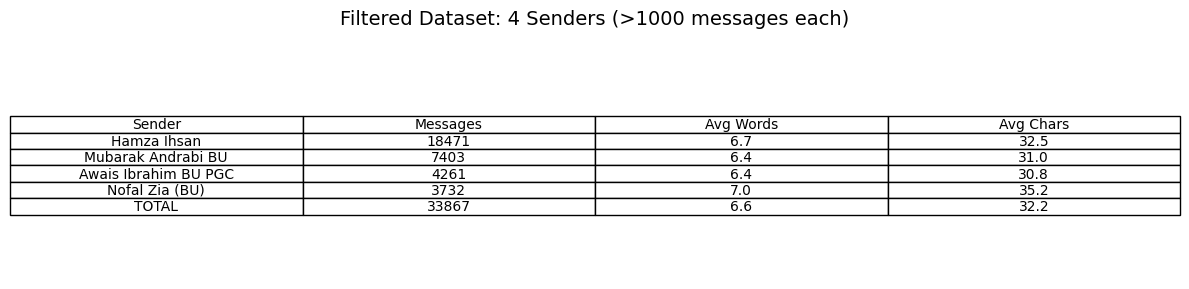

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Count messages per sender in filtered df
counts = df_filtered['sender'].value_counts()

# Create the table plot
fig, ax = plt.subplots(figsize=(12, len(counts) * 0.5 + 1))

# Remove axes
ax.axis('tight')
ax.axis('off')

# Create table data
table_data = []
total_messages = 0
total_chars = 0
total_words = 0

for sender in counts.index:
    sender_df = df_filtered[df_filtered['sender'] == sender]
    msg_count = len(sender_df)
    avg_words = round(sender_df['word_count'].mean(), 1)
    avg_chars = round(sender_df['char_count'].mean(), 1)
    total_messages += msg_count
    total_words += sender_df['word_count'].sum()
    total_chars += sender_df['char_count'].sum()
    
    table_data.append([
        sender,
        msg_count,
        avg_words,
        avg_chars
    ])

# Add total row
table_data.append([
    'TOTAL',
    total_messages,
    round(total_words/total_messages, 1),
    round(total_chars/total_messages, 1)
])

# Create the table
columns = ['Sender', 'Messages', 'Avg Words', 'Avg Chars']
ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

plt.title(f'Filtered Dataset: {len(counts)} Senders (>1000 messages each)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [4]:
# # Reset index first
# df_filtered = df_filtered.reset_index(drop=True)

# # Count per sender
# sender_counts = df_filtered['sender'].value_counts()
# print("Counts:", sender_counts)

# # Manual downsampling without groupby
# TARGET_SIZE = 1100
# balanced_dfs = []

# for sender in df_filtered['sender'].unique():
#     sender_data = df_filtered[df_filtered['sender'] == sender]
#     n = min(TARGET_SIZE, len(sender_data))
#     sampled = sender_data.sample(n=n, random_state=42)
#     balanced_dfs.append(sampled)

# df_balanced = pd.concat(balanced_dfs, ignore_index=True)

# print(f"\nBefore: {len(df_filtered)} messages from {df_filtered['sender'].nunique()} senders")
# print(f"After: {len(df_balanced)} messages from {df_balanced['sender'].nunique()} senders")
# print("\nPer sender:")
# print(df_balanced['sender'].value_counts())


# df_balanced = df_filtered



import numpy as np

# Remove the old random sampling, replace with word-count weighted sampling
TARGET_SIZE = 3000

# First, let's see the overall word count distribution
all_word_counts = df_filtered['word_count']
print(f"Overall word count stats:")
print(f"  Mean: {all_word_counts.mean():.1f}")
print(f"  Std: {all_word_counts.std():.1f}")
print(f"  Min: {all_word_counts.min()}")
print(f"  Max: {all_word_counts.max()}")

# Create target bell curve distribution
# Center around mean=8, std=5 (typical chat message distribution)
target_mean = 10
target_std = 6

# Generate 1100 word counts following normal distribution
np.random.seed(42)
target_word_counts = np.random.normal(target_mean, target_std, TARGET_SIZE)
target_word_counts = np.clip(target_word_counts, 1, None)  # No negative or zero
target_word_counts = np.round(target_word_counts).astype(int)

# Show target distribution
print(f"\nTarget distribution ({TARGET_SIZE} messages):")
print(f"  Mean: {target_word_counts.mean():.1f}")
print(f"  Std: {target_word_counts.std():.1f}")
print(f"  Range: {target_word_counts.min()} - {target_word_counts.max()}")

# For each sender, sample messages to match this distribution
balanced_dfs_bell = []

for sender in df_filtered['sender'].unique():
    sender_data = df_filtered[df_filtered['sender'] == sender].copy()
    
    if len(sender_data) < TARGET_SIZE:
        # If sender has fewer than target, take all
        sampled = sender_data
    else:
        # Try to match the bell curve distribution
        sampled_list = []
        sender_data = sender_data.reset_index(drop=True)
        
        # For each target word count, find a close match in sender's actual messages
        for target_wc in target_word_counts:
            # Find messages closest to target word count
            sender_data['wc_diff'] = abs(sender_data['word_count'] - target_wc)
            closest_idx = sender_data['wc_diff'].idxmin()
            
            sampled_list.append(sender_data.loc[closest_idx])
            sender_data = sender_data.drop(closest_idx)
        
        sampled = pd.DataFrame(sampled_list)
    
    balanced_dfs_bell.append(sampled)

df_balanced = pd.concat(balanced_dfs_bell, ignore_index=True)

# Show the resulting distribution
print(f"\nResulting distribution:")
print(df_balanced['word_count'].describe())
print(f"\nMessages per sender:")
print(df_balanced['sender'].value_counts())

Overall word count stats:
  Mean: 6.6
  Std: 5.7
  Min: 3
  Max: 100

Target distribution (3000 messages):
  Mean: 10.3
  Std: 5.6
  Range: 1 - 34



Resulting distribution:
count    12000.000000
mean         8.472333
std          5.003864
min          3.000000
25%          5.000000
50%          7.000000
75%         11.000000
max         52.000000
Name: word_count, dtype: float64

Messages per sender:
sender
Nofal Zia (BU)          3000
Hamza Ihsan             3000
Mubarak Andrabi BU      3000
Awais Ibrahim BU PGC    3000
Name: count, dtype: int64


In [5]:
# Check if 'sender' column exists and what columns we have
print("Columns in df_filtered:", df_filtered.columns.tolist())


Columns in df_filtered: ['message_id', 'sender', 'word_count', 'char_count', 'message_clean', 'message_clean_lower', 'split']


In [6]:
from sklearn.model_selection import train_test_split

# Create new column for our custom split
df_balanced['custom_split'] = 'train'

# For each sender, randomly assign 80% to train, 20% to test
for sender in df_balanced['sender'].unique():
    sender_mask = df_balanced['sender'] == sender
    sender_indices = df_balanced[sender_mask].index
    
    train_idx, test_idx = train_test_split(
        sender_indices, 
        test_size=0.2, 
        random_state=42
    )
    
    df_balanced.loc[test_idx, 'custom_split'] = 'test'

# Verify the split
print("Split distribution per sender:")
for sender in df_balanced['sender'].unique():
    sender_data = df_balanced[df_balanced['sender'] == sender]
    train_count = (sender_data['custom_split'] == 'train').sum()
    test_count = (sender_data['custom_split'] == 'test').sum()
    print(f"  {sender[:30]}: {train_count} train, {test_count} test")

print(f"\nTotal: {len(df_balanced)} messages")
print(f"Train: {(df_balanced['custom_split']=='train').sum()} ({(df_balanced['custom_split']=='train').sum()/len(df_balanced)*100:.1f}%)")
print(f"Test: {(df_balanced['custom_split']=='test').sum()} ({(df_balanced['custom_split']=='test').sum()/len(df_balanced)*100:.1f}%)")

Split distribution per sender:
  Nofal Zia (BU): 2400 train, 600 test
  Hamza Ihsan: 2400 train, 600 test
  Mubarak Andrabi BU: 2400 train, 600 test
  Awais Ibrahim BU PGC: 2400 train, 600 test

Total: 12000 messages
Train: 9600 (80.0%)
Test: 2400 (20.0%)


Train: 9600 messages
Test: 2400 messages


Overall Accuracy: 0.4163 (41.62%)

Per-Sender Metrics (sorted by F1):
                      precision  recall  f1-score  support
Awais Ibrahim BU PGC   0.484551   0.575  0.525915    600.0
Nofal Zia (BU)         0.420792   0.425  0.422886    600.0
Mubarak Andrabi BU     0.429338   0.400  0.414150    600.0
Hamza Ihsan            0.304015   0.265  0.283170    600.0


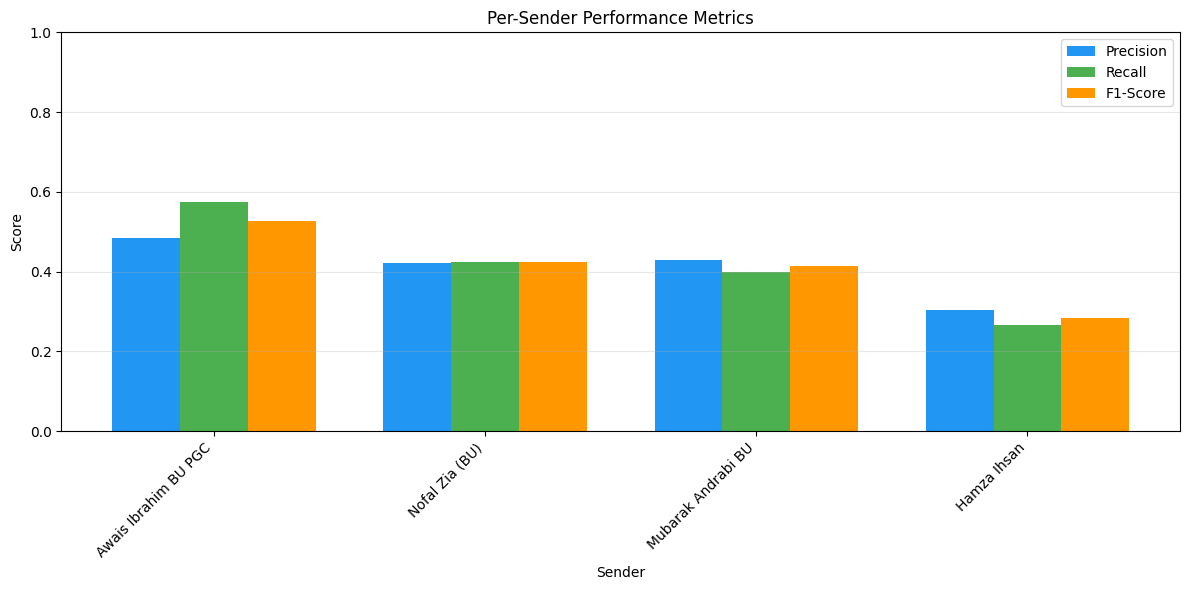

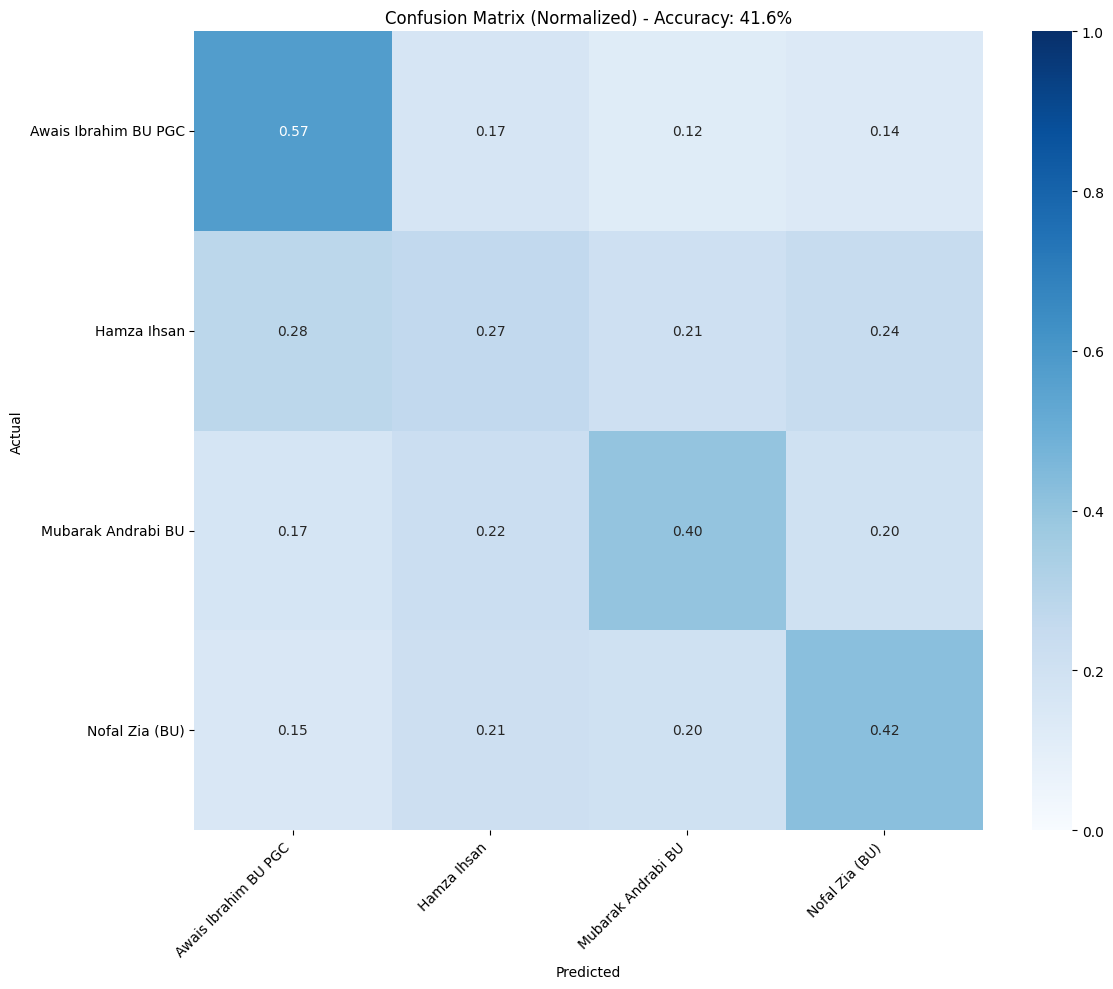

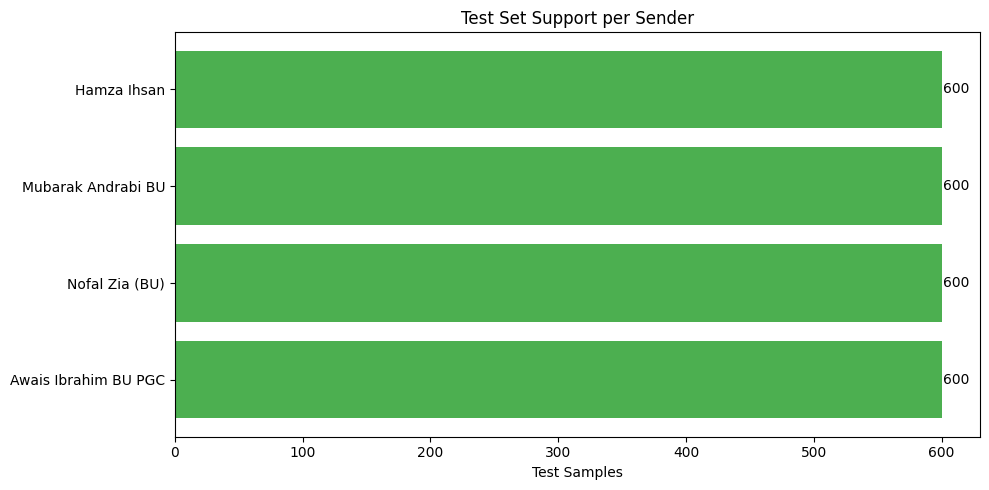

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# ============================================================
# TRAIN MODEL
# ============================================================
if 'custom_split' not in df_balanced.columns:
    df_balanced = df_balanced.copy()
    df_balanced['custom_split'] = 'train'
    for sender in df_balanced['sender'].unique():
        sender_mask = df_balanced['sender'] == sender
        sender_indices = df_balanced[sender_mask].index
        train_idx, test_idx = train_test_split(
            sender_indices,
            test_size=0.2,
            random_state=42
        )
        df_balanced.loc[test_idx, 'custom_split'] = 'test'

train_data = df_balanced[(df_balanced['custom_split'] == 'train') & (df_balanced['word_count'] >= 3)]
test_data = df_balanced[(df_balanced['custom_split'] == 'test') & (df_balanced['word_count'] >= 3)]

print(f"Train: {len(train_data)} messages")
print(f"Test: {len(test_data)} messages")

vectorizer = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)

X_train = vectorizer.fit_transform(train_data['message_clean_lower'])
X_test = vectorizer.transform(test_data['message_clean_lower'])
y_train = train_data['sender']
y_test = test_data['sender']

model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)

# ============================================================
# EVALUATE
# ============================================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dataframe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove support/avg rows for per-sender metrics
sender_metrics = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Sort by F1-score
sender_metrics_sorted = sender_metrics.sort_values('f1-score', ascending=False)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nPer-Sender Metrics (sorted by F1):")
print(sender_metrics_sorted[['precision', 'recall', 'f1-score', 'support']])

# ---- PLOT 1: Per-Sender F1, Precision, Recall ----
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(sender_metrics_sorted))
width = 0.25

ax.bar(x - width, sender_metrics_sorted['precision'], width, label='Precision', color='#2196F3')
ax.bar(x, sender_metrics_sorted['recall'], width, label='Recall', color='#4CAF50')
ax.bar(x + width, sender_metrics_sorted['f1-score'], width, label='F1-Score', color='#FF9800')

ax.set_xlabel('Sender')
ax.set_ylabel('Score')
ax.set_title('Per-Sender Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sender_metrics_sorted.index], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

# Normalize by row (recall)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            xticklabels=[l[:20] for l in labels],
            yticklabels=[l[:20] for l in labels],
            ax=ax,
            vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Normalized) - Accuracy: {accuracy*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- PLOT 3: Support (test samples per sender) ----
fig, ax = plt.subplots(figsize=(10, 5))
supports = sender_metrics_sorted['support']
colors = ['#4CAF50' if s >= 100 else '#FFC107' if s >= 50 else '#F44336' for s in supports]
ax.barh(range(len(supports)), supports, color=colors)
ax.set_yticks(range(len(supports)))
ax.set_yticklabels([s[:30] for s in sender_metrics_sorted.index])
ax.set_xlabel('Test Samples')
ax.set_title('Test Set Support per Sender')
for i, v in enumerate(supports):
    ax.text(v + 1, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

Train: 9600 messages
Test: 2400 messages


Overall Accuracy: 0.4163 (41.62%)

Per-Sender Metrics (sorted by F1):
                      precision    recall  f1-score  support
Awais Ibrahim BU PGC   0.489943  0.568333  0.526235    600.0
Nofal Zia (BU)         0.419355  0.411667  0.415475    600.0
Mubarak Andrabi BU     0.418685  0.403333  0.410866    600.0
Hamza Ihsan            0.314711  0.281667  0.297274    600.0


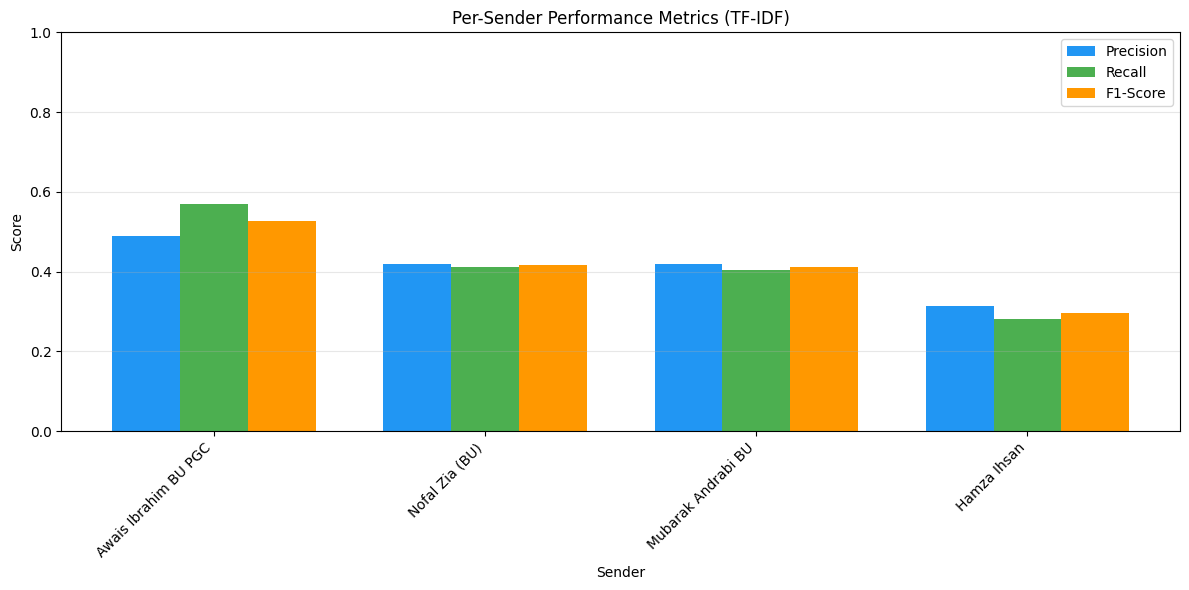

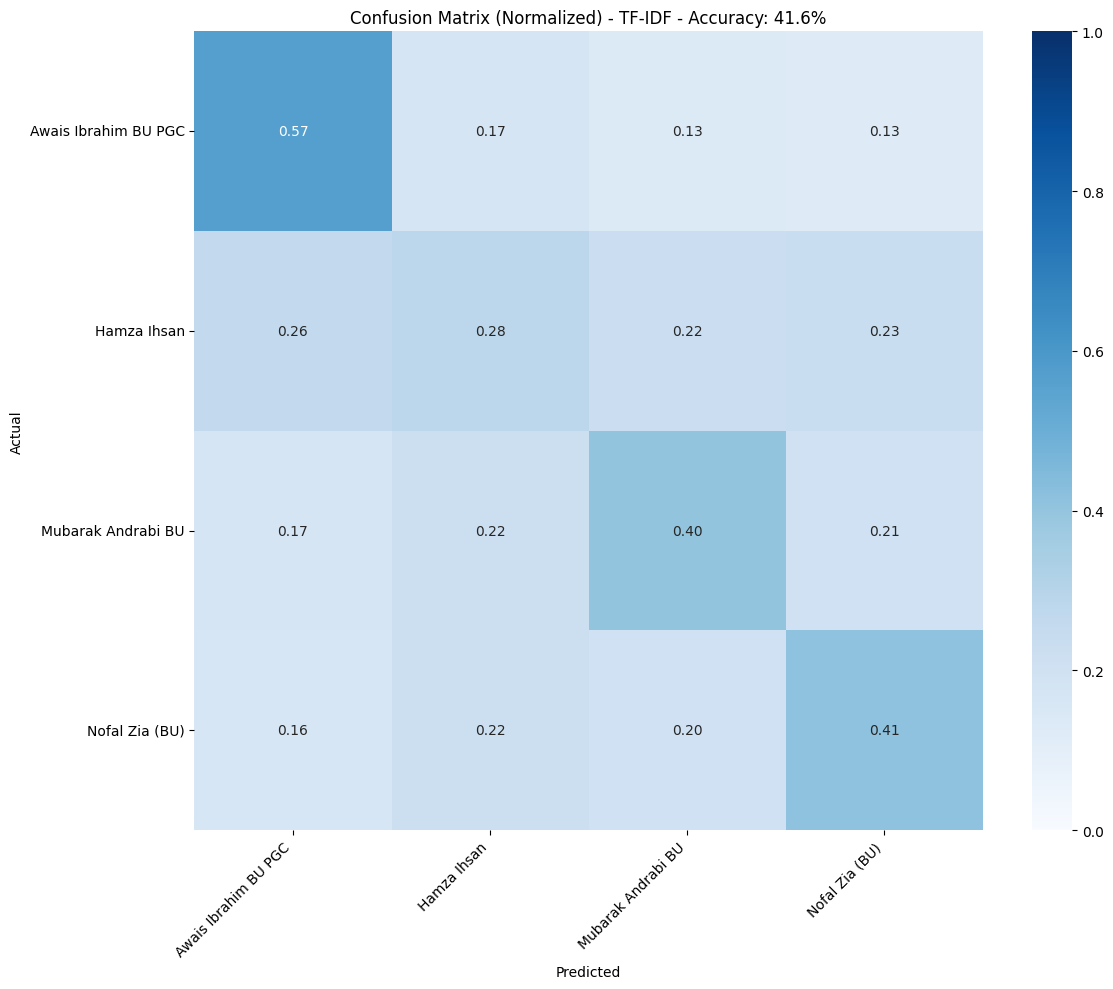

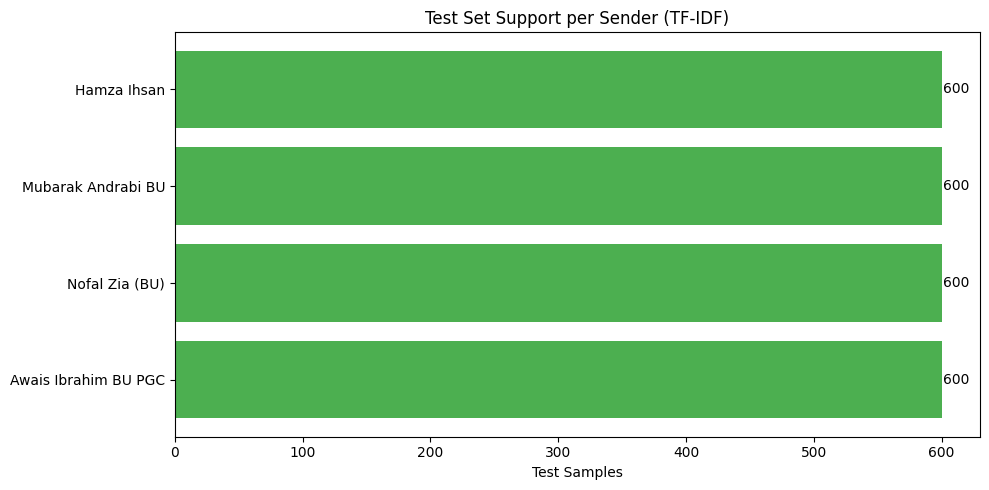

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# ============================================================
# TRAIN MODEL - TF-IDF
# ============================================================
train_data = df_balanced[(df_balanced['custom_split'] == 'train') & (df_balanced['word_count'] >= 3)]
test_data = df_balanced[(df_balanced['custom_split'] == 'test') & (df_balanced['word_count'] >= 3)]

print(f"Train: {len(train_data)} messages")
print(f"Test: {len(test_data)} messages")

vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)

X_train = vectorizer.fit_transform(train_data['message_clean_lower'])
X_test = vectorizer.transform(test_data['message_clean_lower'])
y_train = train_data['sender']
y_test = test_data['sender']

model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)

# ============================================================
# EVALUATE
# ============================================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dataframe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove support/avg rows for per-sender metrics
sender_metrics = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Sort by F1-score
sender_metrics_sorted = sender_metrics.sort_values('f1-score', ascending=False)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nPer-Sender Metrics (sorted by F1):")
print(sender_metrics_sorted[['precision', 'recall', 'f1-score', 'support']])

# ---- PLOT 1: Per-Sender F1, Precision, Recall ----
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(sender_metrics_sorted))
width = 0.25

ax.bar(x - width, sender_metrics_sorted['precision'], width, label='Precision', color='#2196F3')
ax.bar(x, sender_metrics_sorted['recall'], width, label='Recall', color='#4CAF50')
ax.bar(x + width, sender_metrics_sorted['f1-score'], width, label='F1-Score', color='#FF9800')

ax.set_xlabel('Sender')
ax.set_ylabel('Score')
ax.set_title('Per-Sender Performance Metrics (TF-IDF)')
ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sender_metrics_sorted.index], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

# Normalize by row (recall)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            xticklabels=[l[:20] for l in labels],
            yticklabels=[l[:20] for l in labels],
            ax=ax,
            vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Normalized) - TF-IDF - Accuracy: {accuracy*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- PLOT 3: Support (test samples per sender) ----
fig, ax = plt.subplots(figsize=(10, 5))
supports = sender_metrics_sorted['support']
colors = ['#4CAF50' if s >= 100 else '#FFC107' if s >= 50 else '#F44336' for s in supports]
ax.barh(range(len(supports)), supports, color=colors)
ax.set_yticks(range(len(supports)))
ax.set_yticklabels([s[:30] for s in sender_metrics_sorted.index])
ax.set_xlabel('Test Samples')
ax.set_title('Test Set Support per Sender (TF-IDF)')
for i, v in enumerate(supports):
    ax.text(v + 1, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

Train: 9600 messages
Test: 2400 messages


Overall Accuracy: 0.3987 (39.88%)

Per-Sender Metrics (sorted by F1):
                      precision    recall  f1-score  support
Awais Ibrahim BU PGC   0.432890  0.596667  0.501752    600.0
Mubarak Andrabi BU     0.436594  0.401667  0.418403    600.0
Nofal Zia (BU)         0.384486  0.380000  0.382230    600.0
Hamza Ihsan            0.303738  0.216667  0.252918    600.0


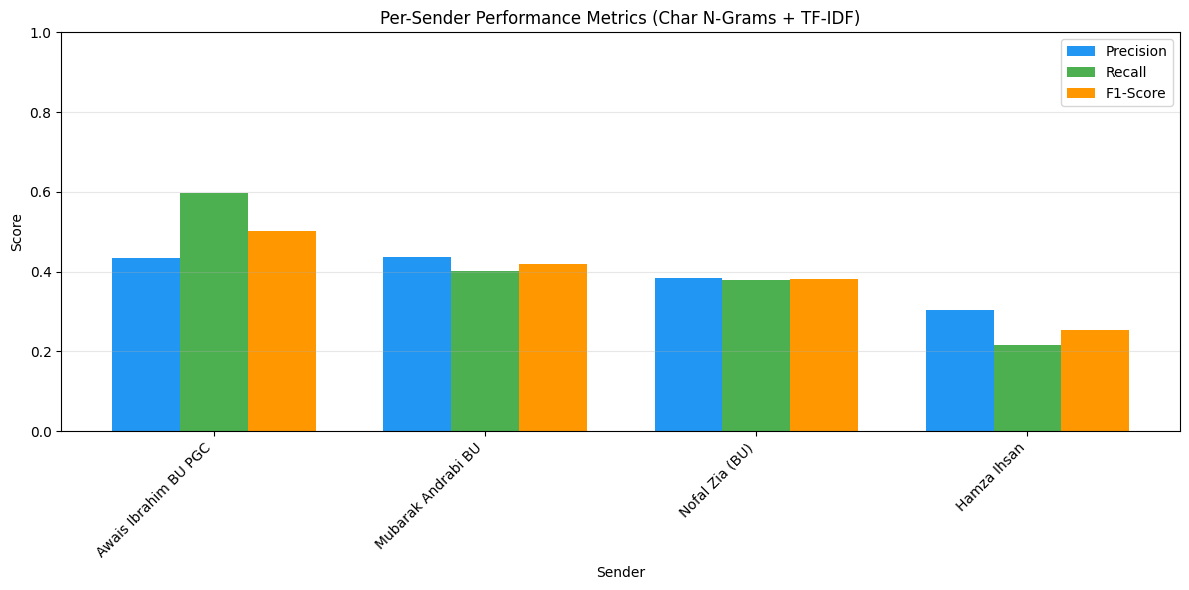

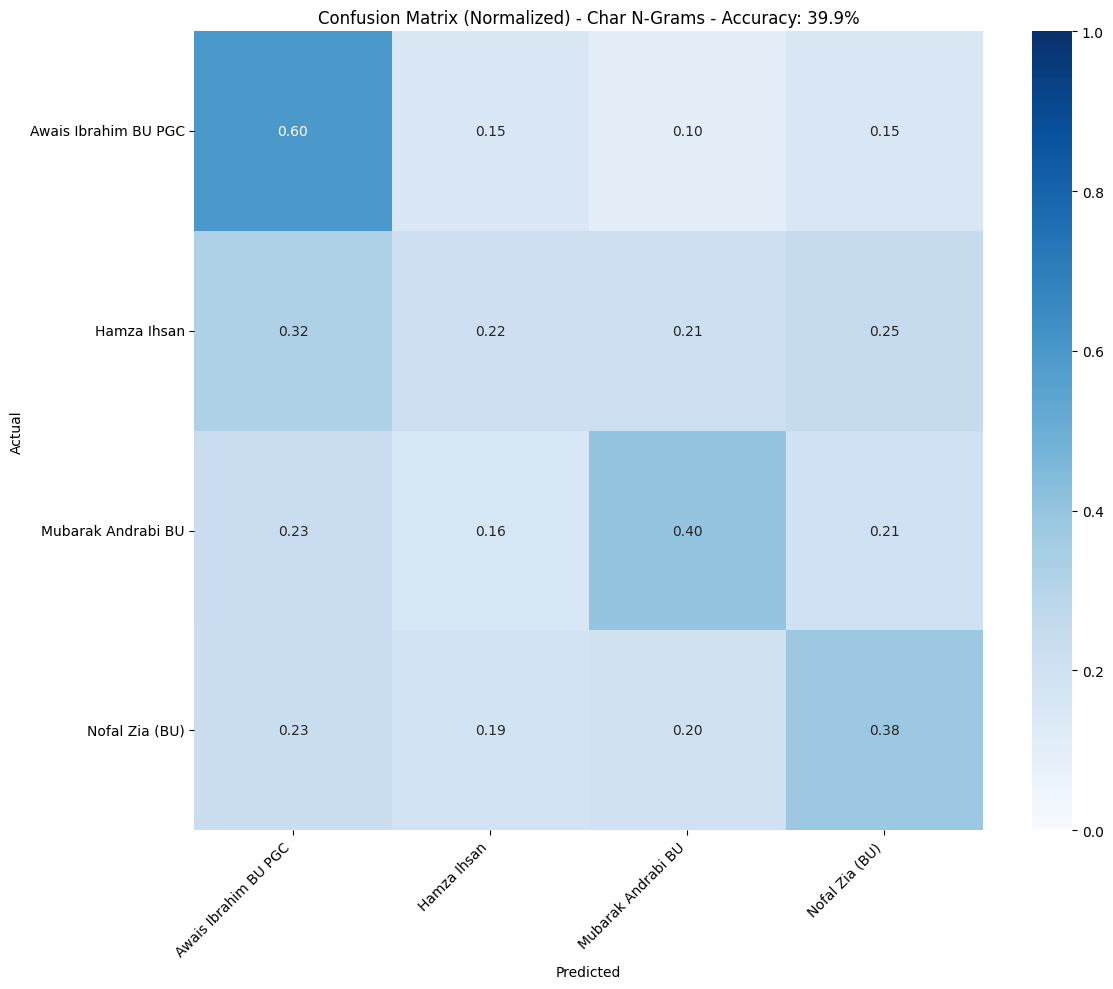

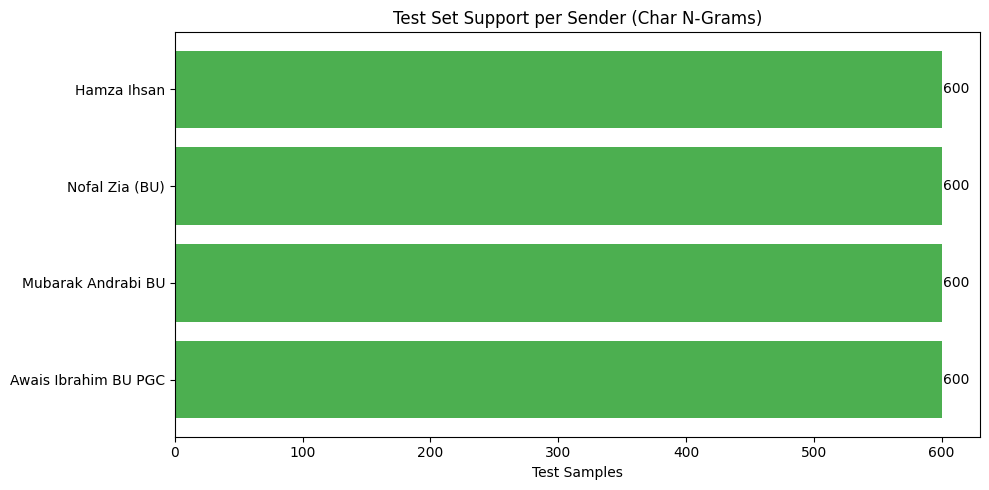

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# ============================================================
# TRAIN MODEL - CHAR N-GRAMS + TF-IDF
# ============================================================
train_data = df_balanced[(df_balanced['custom_split'] == 'train') & (df_balanced['word_count'] >= 3)]
test_data = df_balanced[(df_balanced['custom_split'] == 'test') & (df_balanced['word_count'] >= 3)]

print(f"Train: {len(train_data)} messages")
print(f"Test: {len(test_data)} messages")

vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2
)

X_train = vectorizer.fit_transform(train_data['message_clean_lower'])
X_test = vectorizer.transform(test_data['message_clean_lower'])
y_train = train_data['sender']
y_test = test_data['sender']

model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)

# ============================================================
# EVALUATE
# ============================================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dataframe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove support/avg rows for per-sender metrics
sender_metrics = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Sort by F1-score
sender_metrics_sorted = sender_metrics.sort_values('f1-score', ascending=False)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nPer-Sender Metrics (sorted by F1):")
print(sender_metrics_sorted[['precision', 'recall', 'f1-score', 'support']])

# ---- PLOT 1: Per-Sender F1, Precision, Recall ----
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(sender_metrics_sorted))
width = 0.25

ax.bar(x - width, sender_metrics_sorted['precision'], width, label='Precision', color='#2196F3')
ax.bar(x, sender_metrics_sorted['recall'], width, label='Recall', color='#4CAF50')
ax.bar(x + width, sender_metrics_sorted['f1-score'], width, label='F1-Score', color='#FF9800')

ax.set_xlabel('Sender')
ax.set_ylabel('Score')
ax.set_title('Per-Sender Performance Metrics (Char N-Grams + TF-IDF)')
ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sender_metrics_sorted.index], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

# Normalize by row (recall)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            xticklabels=[l[:20] for l in labels],
            yticklabels=[l[:20] for l in labels],
            ax=ax,
            vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Normalized) - Char N-Grams - Accuracy: {accuracy*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- PLOT 3: Support (test samples per sender) ----
fig, ax = plt.subplots(figsize=(10, 5))
supports = sender_metrics_sorted['support']
colors = ['#4CAF50' if s >= 100 else '#FFC107' if s >= 50 else '#F44336' for s in supports]
ax.barh(range(len(supports)), supports, color=colors)
ax.set_yticks(range(len(supports)))
ax.set_yticklabels([s[:30] for s in sender_metrics_sorted.index])
ax.set_xlabel('Test Samples')
ax.set_title('Test Set Support per Sender (Char N-Grams)')
for i, v in enumerate(supports):
    ax.text(v + 1, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

Train: 9600 messages
Test: 2400 messages


Overall Accuracy: 0.4254 (42.54%)

Per-Sender Metrics (sorted by F1):
                      precision    recall  f1-score  support
Awais Ibrahim BU PGC   0.473997  0.531667  0.501178    600.0
Mubarak Andrabi BU     0.431900  0.401667  0.416235    600.0
Nofal Zia (BU)         0.409462  0.418333  0.413850    600.0
Hamza Ihsan            0.377698  0.350000  0.363322    600.0


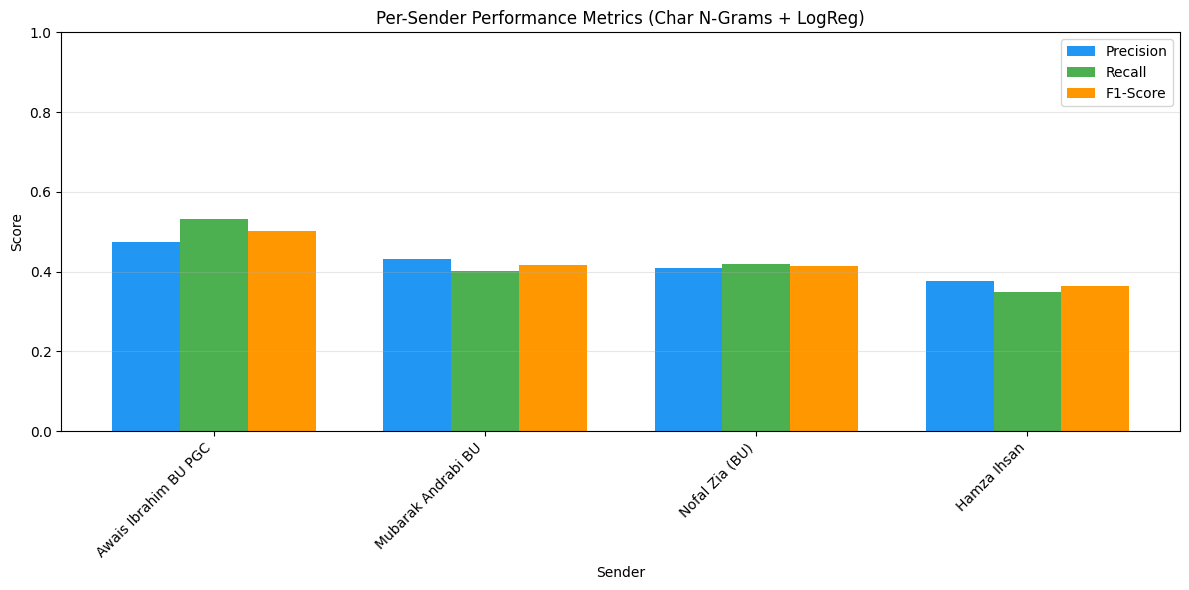

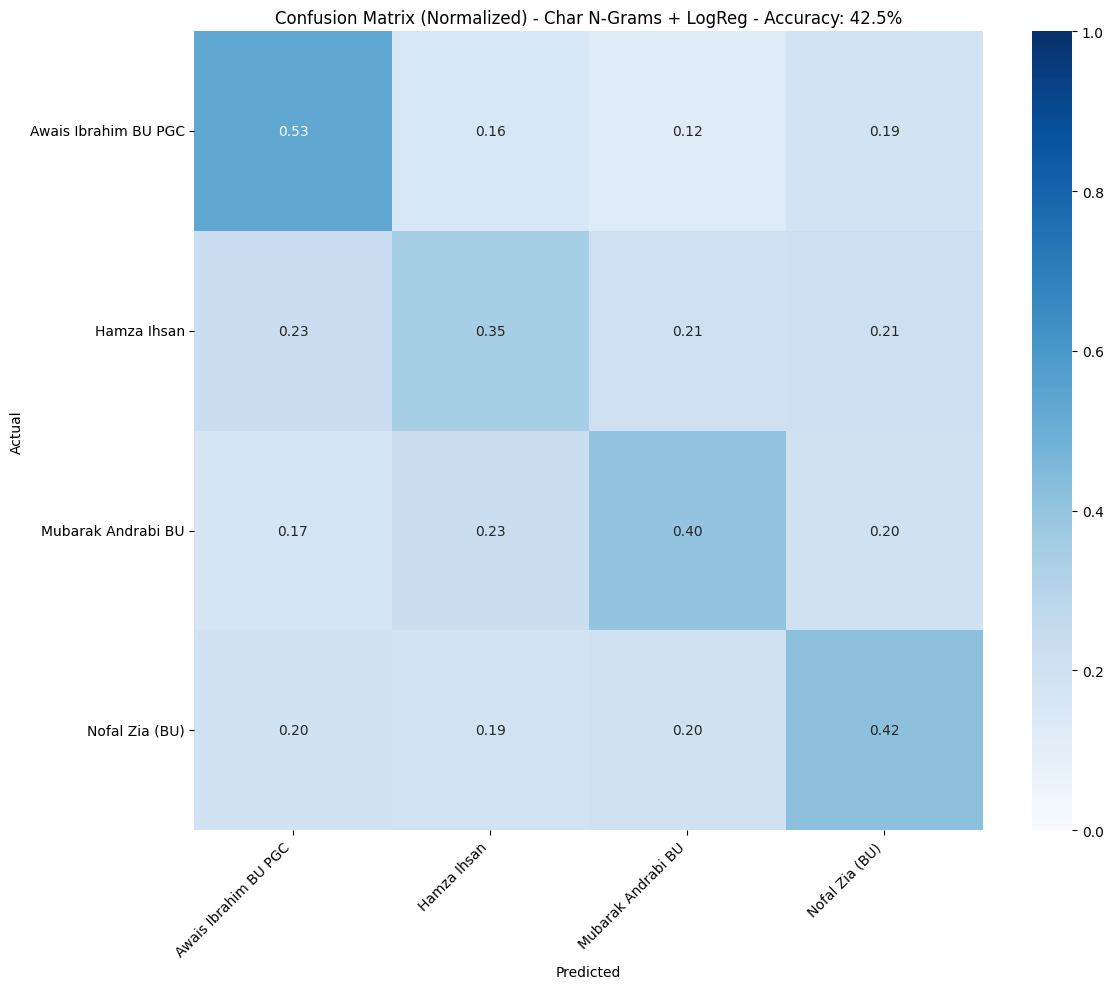

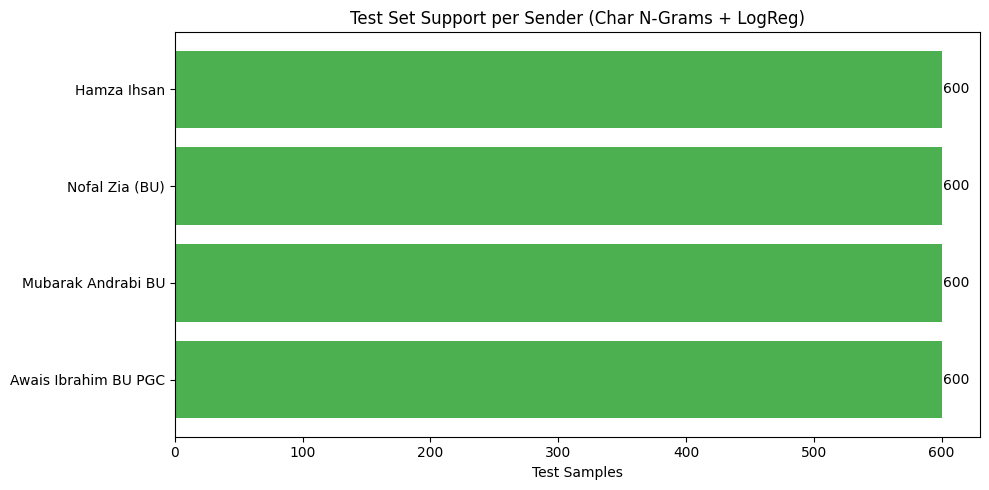

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd

# ============================================================
# TRAIN MODEL - CHAR N-GRAMS + LOGISTIC REGRESSION
# ============================================================
if 'custom_split' not in df_balanced.columns:
    df_balanced = df_balanced.copy()
    df_balanced['custom_split'] = 'train'
    for sender in df_balanced['sender'].unique():
        sender_mask = df_balanced['sender'] == sender
        sender_indices = df_balanced[sender_mask].index
        train_idx, test_idx = train_test_split(
            sender_indices,
            test_size=0.2,
            random_state=42
        )
        df_balanced.loc[test_idx, 'custom_split'] = 'test'

train_data = df_balanced[(df_balanced['custom_split'] == 'train') & (df_balanced['word_count'] >= 3)]
test_data = df_balanced[(df_balanced['custom_split'] == 'test') & (df_balanced['word_count'] >= 3)]

print(f"Train: {len(train_data)} messages")
print(f"Test: {len(test_data)} messages")

vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2
)

X_train = vectorizer.fit_transform(train_data['message_clean_lower'])
X_test = vectorizer.transform(test_data['message_clean_lower'])
y_train = train_data['sender']
y_test = test_data['sender']

model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced'
)
model.fit(X_train, y_train)

# ============================================================
# EVALUATE
# ============================================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dataframe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove support/avg rows for per-sender metrics
sender_metrics = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Sort by F1-score
sender_metrics_sorted = sender_metrics.sort_values('f1-score', ascending=False)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nPer-Sender Metrics (sorted by F1):")
print(sender_metrics_sorted[['precision', 'recall', 'f1-score', 'support']])

# ---- PLOT 1: Per-Sender F1, Precision, Recall ----
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(sender_metrics_sorted))
width = 0.25

ax.bar(x - width, sender_metrics_sorted['precision'], width, label='Precision', color='#2196F3')
ax.bar(x, sender_metrics_sorted['recall'], width, label='Recall', color='#4CAF50')
ax.bar(x + width, sender_metrics_sorted['f1-score'], width, label='F1-Score', color='#FF9800')

ax.set_xlabel('Sender')
ax.set_ylabel('Score')
ax.set_title('Per-Sender Performance Metrics (Char N-Grams + LogReg)')
ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sender_metrics_sorted.index], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

# Normalize by row (recall)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            xticklabels=[l[:20] for l in labels],
            yticklabels=[l[:20] for l in labels],
            ax=ax,
            vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Normalized) - Char N-Grams + LogReg - Accuracy: {accuracy*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- PLOT 3: Support (test samples per sender) ----
fig, ax = plt.subplots(figsize=(10, 5))
supports = sender_metrics_sorted['support']
colors = ['#4CAF50' if s >= 100 else '#FFC107' if s >= 50 else '#F44336' for s in supports]
ax.barh(range(len(supports)), supports, color=colors)
ax.set_yticks(range(len(supports)))
ax.set_yticklabels([s[:30] for s in sender_metrics_sorted.index])
ax.set_xlabel('Test Samples')
ax.set_title('Test Set Support per Sender (Char N-Grams + LogReg)')
for i, v in enumerate(supports):
    ax.text(v + 1, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

Train: 9600 messages
Test: 2400 messages



Using handcrafted features: ['char_count', 'word_count']
Combined features: 8002 (text: 8000, handcrafted: 2)

Overall Accuracy: 0.4192 (41.92%)

Per-Sender Metrics (sorted by F1):
                      precision    recall  f1-score  support
Awais Ibrahim BU PGC   0.488636  0.573333  0.527607    600.0
Nofal Zia (BU)         0.420290  0.435000  0.427518    600.0
Mubarak Andrabi BU     0.435484  0.405000  0.419689    600.0
Hamza Ihsan            0.305609  0.263333  0.282901    600.0


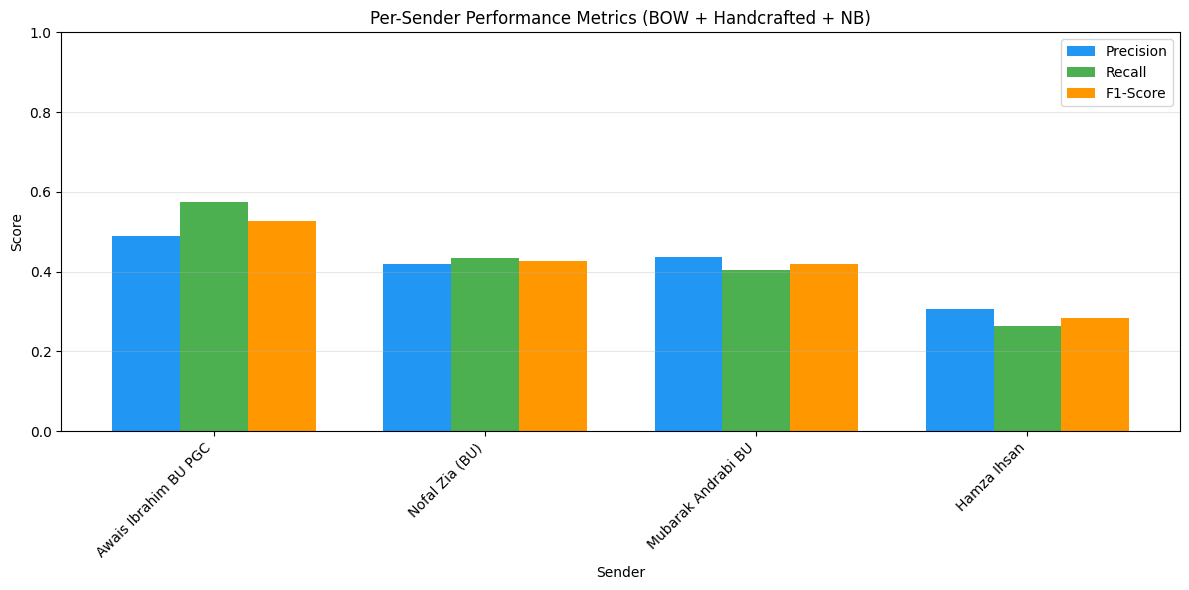

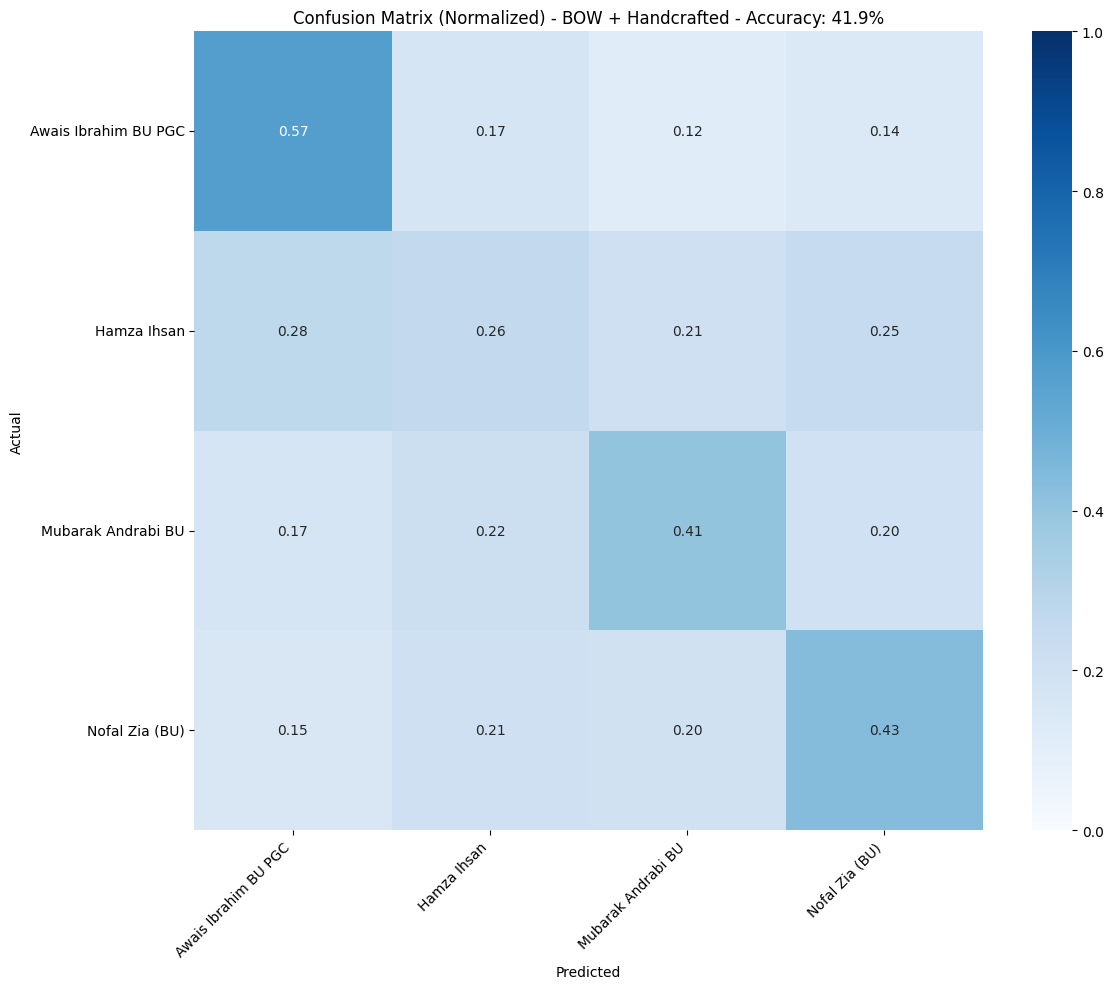

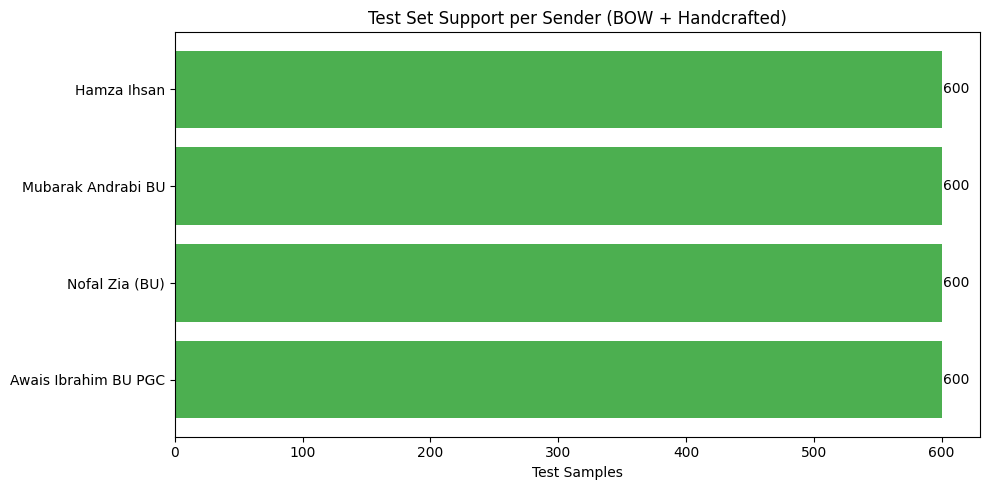

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix
import pandas as pd

# ============================================================
# TRAIN MODEL - WORD BOW + HANDCRAFTED FEATURES + NAIVE BAYES
# ============================================================
if 'custom_split' not in df_balanced.columns:
    df_balanced = df_balanced.copy()
    df_balanced['custom_split'] = 'train'
    for sender in df_balanced['sender'].unique():
        sender_mask = df_balanced['sender'] == sender
        sender_indices = df_balanced[sender_mask].index
        train_idx, test_idx = train_test_split(
            sender_indices,
            test_size=0.2,
            random_state=42
        )
        df_balanced.loc[test_idx, 'custom_split'] = 'test'

train_data = df_balanced[(df_balanced['custom_split'] == 'train') & (df_balanced['word_count'] >= 3)].copy()
test_data = df_balanced[(df_balanced['custom_split'] == 'test') & (df_balanced['word_count'] >= 3)].copy()

print(f"Train: {len(train_data)} messages")
print(f"Test: {len(test_data)} messages")

# --- Text features (BOW) ---
vectorizer = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=8000,
    min_df=2
)

X_train_text = vectorizer.fit_transform(train_data['message_clean_lower'])
X_test_text = vectorizer.transform(test_data['message_clean_lower'])

# --- Handcrafted features ---
handcrafted_cols = [
    'char_count',
    'word_count',
    'avg_word_length',
    'uppercase_ratio',
    'punctuation_count',
    'digit_count',
    'emoji_count',
    'has_emoji',
    'question_mark_count',
    'exclamation_count',
    'url_count',
    'language_mix_ratio'
]

# Check which columns exist
available_cols = [col for col in handcrafted_cols if col in train_data.columns]
print(f"\nUsing handcrafted features: {available_cols}")

scaler = MinMaxScaler()
X_train_hand = scaler.fit_transform(train_data[available_cols].fillna(0))
X_test_hand = scaler.transform(test_data[available_cols].fillna(0))

# Convert to sparse for compatibility
X_train_hand_sparse = csr_matrix(X_train_hand)
X_test_hand_sparse = csr_matrix(X_test_hand)

# --- Combine text + handcrafted ---
X_train = hstack([X_train_text, X_train_hand_sparse])
X_test = hstack([X_test_text, X_test_hand_sparse])

print(f"Combined features: {X_train.shape[1]} (text: {X_train_text.shape[1]}, handcrafted: {X_train_hand_sparse.shape[1]})")

y_train = train_data['sender']
y_test = test_data['sender']

model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)

# ============================================================
# EVALUATE
# ============================================================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Classification report as dataframe
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove support/avg rows for per-sender metrics
sender_metrics = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Sort by F1-score
sender_metrics_sorted = sender_metrics.sort_values('f1-score', ascending=False)

print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nPer-Sender Metrics (sorted by F1):")
print(sender_metrics_sorted[['precision', 'recall', 'f1-score', 'support']])

# ---- PLOT 1: Per-Sender F1, Precision, Recall ----
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(sender_metrics_sorted))
width = 0.25

ax.bar(x - width, sender_metrics_sorted['precision'], width, label='Precision', color='#2196F3')
ax.bar(x, sender_metrics_sorted['recall'], width, label='Recall', color='#4CAF50')
ax.bar(x + width, sender_metrics_sorted['f1-score'], width, label='F1-Score', color='#FF9800')

ax.set_xlabel('Sender')
ax.set_ylabel('Score')
ax.set_title('Per-Sender Performance Metrics (BOW + Handcrafted + NB)')
ax.set_xticks(x)
ax.set_xticklabels([s[:25] for s in sender_metrics_sorted.index], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---- PLOT 2: Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

# Normalize by row (recall)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_normalized, 
            annot=True, 
            fmt='.2f', 
            cmap='Blues',
            xticklabels=[l[:20] for l in labels],
            yticklabels=[l[:20] for l in labels],
            ax=ax,
            vmin=0, vmax=1)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Normalized) - BOW + Handcrafted - Accuracy: {accuracy*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- PLOT 3: Support (test samples per sender) ----
fig, ax = plt.subplots(figsize=(10, 5))
supports = sender_metrics_sorted['support']
colors = ['#4CAF50' if s >= 100 else '#FFC107' if s >= 50 else '#F44336' for s in supports]
ax.barh(range(len(supports)), supports, color=colors)
ax.set_yticks(range(len(supports)))
ax.set_yticklabels([s[:30] for s in sender_metrics_sorted.index])
ax.set_xlabel('Test Samples')
ax.set_title('Test Set Support per Sender (BOW + Handcrafted)')
for i, v in enumerate(supports):
    ax.text(v + 1, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

Train: 9600 messages
Test: 2400 messages



Ensemble Accuracy: 0.4233 (42.33%)

Per-Sender Metrics (sorted by F1):
                      precision    recall  f1-score  support
Awais Ibrahim BU PGC   0.482094  0.583333  0.527903    600.0
Nofal Zia (BU)         0.423138  0.445000  0.433794    600.0
Mubarak Andrabi BU     0.434705  0.405000  0.419327    600.0
Hamza Ihsan            0.322314  0.260000  0.287823    600.0

Model comparison:
                 model  accuracy
  Char TF-IDF + LogReg  0.425417
              Ensemble  0.423333
BOW + Handcrafted + NB  0.419167
              BOW + NB  0.416250
           TF-IDF + NB  0.416250
      Char TF-IDF + NB  0.398750


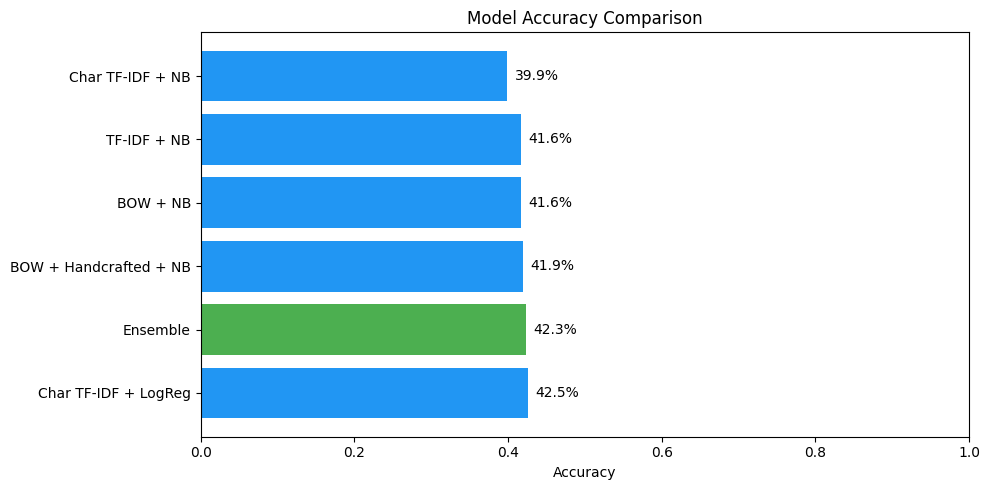

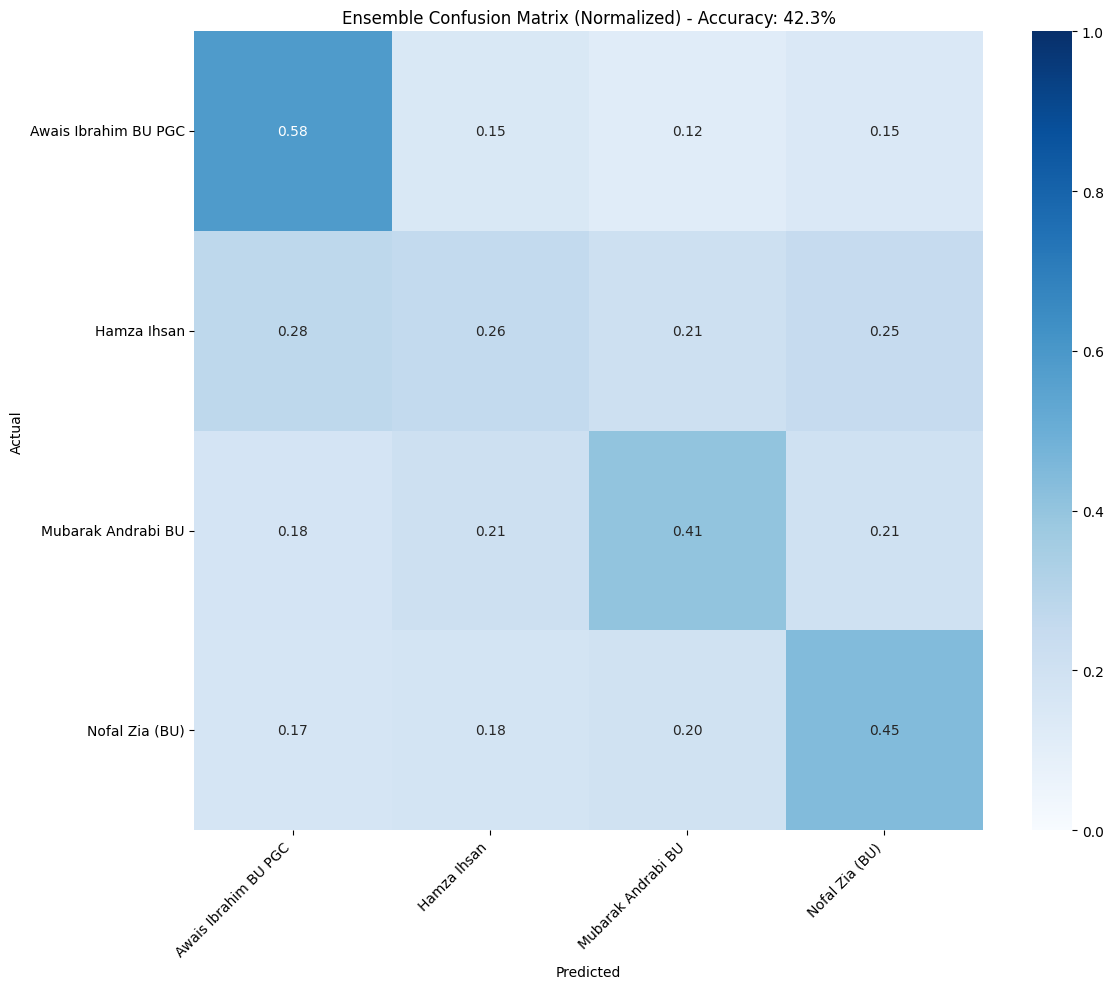

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# ============================================================
# ENSEMBLE LEARNING - ALL MODELS
# ============================================================
if 'custom_split' not in df_balanced.columns:
    df_balanced = df_balanced.copy()
    df_balanced['custom_split'] = 'train'
    for sender in df_balanced['sender'].unique():
        sender_mask = df_balanced['sender'] == sender
        sender_indices = df_balanced[sender_mask].index
        train_idx, test_idx = train_test_split(
            sender_indices,
            test_size=0.2,
            random_state=42
        )
        df_balanced.loc[test_idx, 'custom_split'] = 'test'

train_data = df_balanced[(df_balanced['custom_split'] == 'train') & (df_balanced['word_count'] >= 3)].copy()
test_data = df_balanced[(df_balanced['custom_split'] == 'test') & (df_balanced['word_count'] >= 3)].copy()

print(f"Train: {len(train_data)} messages")
print(f"Test: {len(test_data)} messages")

# --- Model 1: Word BOW + Naive Bayes ---
bow_vectorizer = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)
X_train_bow = bow_vectorizer.fit_transform(train_data['message_clean_lower'])
X_test_bow = bow_vectorizer.transform(test_data['message_clean_lower'])
bow_model = MultinomialNB(alpha=0.5)
bow_model.fit(X_train_bow, train_data['sender'])
bow_proba = bow_model.predict_proba(X_test_bow)

# --- Model 2: TF-IDF Word N-Grams + Naive Bayes ---
tfidf_word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2
)
X_train_tfidf_word = tfidf_word_vectorizer.fit_transform(train_data['message_clean_lower'])
X_test_tfidf_word = tfidf_word_vectorizer.transform(test_data['message_clean_lower'])
tfidf_word_model = MultinomialNB(alpha=0.5)
tfidf_word_model.fit(X_train_tfidf_word, train_data['sender'])
tfidf_word_proba = tfidf_word_model.predict_proba(X_test_tfidf_word)

# --- Model 3: Char N-Grams + TF-IDF + Naive Bayes ---
char_tfidf_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2
)
X_train_char_tfidf = char_tfidf_vectorizer.fit_transform(train_data['message_clean_lower'])
X_test_char_tfidf = char_tfidf_vectorizer.transform(test_data['message_clean_lower'])
char_tfidf_model = MultinomialNB(alpha=0.5)
char_tfidf_model.fit(X_train_char_tfidf, train_data['sender'])
char_tfidf_proba = char_tfidf_model.predict_proba(X_test_char_tfidf)

# --- Model 4: Char N-Grams + TF-IDF + Logistic Regression ---
char_lr_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2
)
X_train_char_lr = char_lr_vectorizer.fit_transform(train_data['message_clean_lower'])
X_test_char_lr = char_lr_vectorizer.transform(test_data['message_clean_lower'])
char_lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced'
)
char_lr_model.fit(X_train_char_lr, train_data['sender'])
char_lr_proba = char_lr_model.predict_proba(X_test_char_lr)

# --- Model 5: BOW + Handcrafted Features + Naive Bayes ---
handcrafted_cols = [
    'char_count',
    'word_count',
    'avg_word_length',
    'uppercase_ratio',
    'punctuation_count',
    'digit_count',
    'emoji_count',
    'has_emoji',
    'question_mark_count',
    'exclamation_count',
    'url_count',
    'language_mix_ratio'
]
available_cols = [col for col in handcrafted_cols if col in train_data.columns]

hand_vectorizer = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=8000,
    min_df=2
)
X_train_hand_text = hand_vectorizer.fit_transform(train_data['message_clean_lower'])
X_test_hand_text = hand_vectorizer.transform(test_data['message_clean_lower'])

scaler = MinMaxScaler()
X_train_hand_feats = scaler.fit_transform(train_data[available_cols].fillna(0))
X_test_hand_feats = scaler.transform(test_data[available_cols].fillna(0))

X_train_hand_combined = hstack([X_train_hand_text, csr_matrix(X_train_hand_feats)])
X_test_hand_combined = hstack([X_test_hand_text, csr_matrix(X_test_hand_feats)])
hand_model = MultinomialNB(alpha=0.5)
hand_model.fit(X_train_hand_combined, train_data['sender'])
hand_proba = hand_model.predict_proba(X_test_hand_combined)

# Ensure class order alignment across all models
ensemble_classes = bow_model.classes_
models_and_proba = [
    ('BOW+NB', bow_model, bow_proba),
    ('TFIDF+NB', tfidf_word_model, tfidf_word_proba),
    ('CHAR+TFIDF+NB', char_tfidf_model, char_tfidf_proba),
    ('CHAR+LR', char_lr_model, char_lr_proba),
    ('BOW+HAND+NB', hand_model, hand_proba),
]

aligned_probas = []
for model_name, fitted_model, proba in models_and_proba:
    if not np.array_equal(fitted_model.classes_, ensemble_classes):
        class_to_index = {label: idx for idx, label in enumerate(fitted_model.classes_)}
        reordered = np.zeros((proba.shape[0], len(ensemble_classes)))
        for target_index, label in enumerate(ensemble_classes):
            reordered[:, target_index] = proba[:, class_to_index[label]]
        proba = reordered
    aligned_probas.append(proba)

# Equal-weight soft voting ensemble
ensemble_proba = np.mean(aligned_probas, axis=0)
ensemble_pred = ensemble_classes[np.argmax(ensemble_proba, axis=1)]
ensemble_accuracy = accuracy_score(test_data['sender'], ensemble_pred)

report = classification_report(test_data['sender'], ensemble_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
sender_metrics = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
sender_metrics_sorted = sender_metrics.sort_values('f1-score', ascending=False)

print(f"\nEnsemble Accuracy: {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")
print("\nPer-Sender Metrics (sorted by F1):")
print(sender_metrics_sorted[['precision', 'recall', 'f1-score', 'support']])

# Compare individual model accuracies
model_predictions = {
    'BOW + NB': bow_model.predict(X_test_bow),
    'TF-IDF + NB': tfidf_word_model.predict(X_test_tfidf_word),
    'Char TF-IDF + NB': char_tfidf_model.predict(X_test_char_tfidf),
    'Char TF-IDF + LogReg': char_lr_model.predict(X_test_char_lr),
    'BOW + Handcrafted + NB': hand_model.predict(X_test_hand_combined),
    'Ensemble': ensemble_pred,
}

comparison_rows = []
for model_name, predictions in model_predictions.items():
    comparison_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(test_data['sender'], predictions)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('accuracy', ascending=False)
print("\nModel comparison:")
print(comparison_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(comparison_df['model'], comparison_df['accuracy'], color=['#4CAF50' if m == 'Ensemble' else '#2196F3' for m in comparison_df['model']])
ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
for idx, value in enumerate(comparison_df['accuracy']):
    ax.text(value + 0.01, idx, f'{value*100:.1f}%', va='center')
plt.tight_layout()
plt.show()

# Confusion matrix for ensemble
cm = confusion_matrix(test_data['sender'], ensemble_pred, labels=ensemble_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=[l[:20] for l in ensemble_classes],
    yticklabels=[l[:20] for l in ensemble_classes],
    ax=ax,
    vmin=0,
    vmax=1,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Ensemble Confusion Matrix (Normalized) - Accuracy: {ensemble_accuracy*100:.1f}%')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()